# Description
Run `database_prep.ipynb` before running this script.

# Imports

In [23]:
import pandas as pd
import os
import numpy as np
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [24]:
root_dir = "/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/UdeM/MSc Psycho/LABO NED - Personal Drive/Code/GENiAL/"
og_data = os.path.join(root_dir, 'Data/Final/GENIAL-DB-preprocessed-V2.csv') # original data
og_data = pd.read_csv(og_data)

# Data Manipulations

Make sure EEG features are numerical

In [25]:
# Make sure EEG_ columns are numeric
# Get all EEG_ columns except known non-numeric ones
non_numeric_cols = ['EEG_attempted', 'EEG_site', 'EEG_date', 'EEG_age', 'EEG_Age', 'EEG_Sex']
eeg_cols = [col for col in og_data.columns if col.startswith('EEG_') and col not in non_numeric_cols]

# Convert EEG columns to numeric, coercing errors to NaN
for col in eeg_cols:
    og_data[col] = pd.to_numeric(og_data[col], errors='coerce')


Remove over 80% EEG features issing rows

In [26]:
# Calculate the percentage of missing values for each row
missing_percentage = og_data[eeg_cols].isnull().mean(axis=1)

# Keep only rows where less than 80% of EEG features are missing
no_missing_data = og_data[missing_percentage < 0.8].reset_index(drop=True)

print(f"Rows remaining after dropping those with >80% missing EEG data: {len(no_missing_data)}")


Rows remaining after dropping those with >80% missing EEG data: 80


In [27]:
diagnostic_groups_data = no_missing_data.copy()

# Add diagnostic group column
# 0: Control (diag_control = 1)
# 1: Neurodev only (diag_neurodev = 1 and diag_genetic_carrier = 0)
# 2: Genetic carrier (diag_genetic_carrier = 1)
diagnostic_groups_data['diagnostic_group'] = 0

# Set group 1: Neurodev only
diagnostic_groups_data.loc[(diagnostic_groups_data['diag_neurodev'] == 1) & (diagnostic_groups_data['diag_genetic_carrier'] == 0), 'diagnostic_group'] = 1

# Set group 2: Genetic carrier
diagnostic_groups_data.loc[diagnostic_groups_data['diag_genetic_carrier'] == 1, 'diagnostic_group'] = 2


In [39]:
# Drop EEG_Age and EEG_Sex columns
diagnostic_groups_data = diagnostic_groups_data.drop(['EEG_Age', 'EEG_Sex'], axis=1)


# Stats

Summarize data

In [28]:
# Get summary statistics for EEG columns
eeg_summary = diagnostic_groups_data[eeg_cols].agg(['min', 'max', 'mean']).round(2)

# Display summary
print("\nEEG Features Summary:")
print(eeg_summary)



EEG Features Summary:
      EEG_Exponent-Frontal  EEG_Exponent-Central  EEG_Exponent-temporal-r  \
min                   0.54                  0.63                     0.52   
max                   1.98                  2.04                     1.99   
mean                  1.35                  1.40                     1.30   

      EEG_Exponent-temporal-l  EEG_Exponent-parietal-r  \
min                      0.31                     0.53   
max                      1.99                     1.98   
mean                     1.33                     1.33   

      EEG_Exponent-parietal-l  EEG_Exponent-Occipital  \
min                      0.27                    0.63   
max                      1.91                    2.04   
mean                     1.32                    1.46   

      EEG_Exponent-WholeBrain  EEG_Offset-Frontal  EEG_Offset-Central  ...  \
min                      0.66                0.15               -0.48  ...   
max                      1.94                2.26 

In [29]:
# Calculate z-scores for each EEG feature within each diagnostic group
z_scores = pd.DataFrame()

for group in diagnostic_groups_data['diagnostic_group'].unique():
    group_data = diagnostic_groups_data[diagnostic_groups_data['diagnostic_group'] == group]
    
    # Calculate z-scores for all EEG columns in this group
    group_z_scores = group_data[eeg_cols].apply(lambda x: (x - x.mean()) / x.std())
    
    # Add group identifier
    group_z_scores['diagnostic_group'] = group
    
    # Append to main z-scores dataframe
    z_scores = pd.concat([z_scores, group_z_scores])

# Reset index of final dataframe
z_scores = z_scores.reset_index(drop=True)

print("\nZ-scores calculated for each diagnostic group")
print(f"Shape of z-scores dataframe: {z_scores.shape}")




Z-scores calculated for each diagnostic group
Shape of z-scores dataframe: (80, 177)


In [30]:
# Check for extreme z-scores (|z| > 3.29)
extreme_mask = (z_scores[eeg_cols].abs() > 3.29)
num_extreme = extreme_mask.sum()

print("\nNumber of extreme z-scores (|z| > 3.29) for each EEG feature:")
print(num_extreme)

# Get columns with extreme scores
columns_with_extremes = [col for col, count in num_extreme.items() if count > 0]
print("\nColumns with extreme scores:")
print(columns_with_extremes)

total_extreme_rows = extreme_mask.any(axis=1).sum()

if total_extreme_rows > 0:
    print(f"\nFound {total_extreme_rows} rows with extreme z-scores")
    print("\nBreakdown by diagnostic group:")
    for group in [0, 1, 2]:
        group_rows = extreme_mask[z_scores['diagnostic_group'] == group].any(axis=1).sum()
        group_name = {
            0: "Control",
            1: "Neurodev only", 
            2: "Genetic carrier"
        }[group]
        print(f"{group_name}: {group_rows} rows with extreme values")
else:
    print("\nNo extreme z-scores found.")



Number of extreme z-scores (|z| > 3.29) for each EEG feature:
EEG_Exponent-Frontal       0
EEG_Exponent-Central       0
EEG_Exponent-temporal-r    0
EEG_Exponent-temporal-l    0
EEG_Exponent-parietal-r    0
                          ..
EEG_DFA-Beta_temporal-l    0
EEG_DFA-Beta_parietal-r    0
EEG_DFA-Beta_parietal-l    0
EEG_DFA-Beta_Occipital     0
EEG_DFA-Beta_WholeBrain    0
Length: 176, dtype: int64

Columns with extreme scores:
['EEG_Delta-Frontal', 'EEG_Delta-temporal-r', 'EEG_Delta-temporal-l', 'EEG_Delta-parietal-r', 'EEG_Delta-parietal-l', 'EEG_Delta-Occipital', 'EEG_Theta-Frontal', 'EEG_Theta-Central', 'EEG_Theta-temporal-r', 'EEG_Theta-temporal-l', 'EEG_Theta-parietal-r', 'EEG_Theta-parietal-l', 'EEG_Theta-Occipital', 'EEG_Theta-WholeBrain', 'EEG_Alpha-Central', 'EEG_Alpha-temporal-r', 'EEG_Alpha-temporal-l', 'EEG_Alpha-parietal-r', 'EEG_Alpha-parietal-l', 'EEG_Alpha-Occipital', 'EEG_Alpha-WholeBrain', 'EEG_Beta-Frontal', 'EEG_Beta-temporal-l', 'EEG_Beta-parietal-r', 'EEG_B

Adjust extreme scores (Z > 3.29)

In [31]:
def adjust_extreme_scores(db, colname):
    # Convert list to array if needed
    if isinstance(db[colname], list):
        db[colname] = np.array(db[colname])
    
    # Convert to numeric
    db[colname] = pd.to_numeric(db[colname])
    
    # Calculate min/max thresholds
    mean = np.nanmean(db[colname])
    std = np.nanstd(db[colname])
    min_val = mean - (3.29 * std)
    max_val = mean + (3.29 * std)
    
    # Replace extreme scores
    db[colname] = np.where(
        pd.isna(db[colname]), 
        np.nan,
        np.where(
            db[colname] < min_val,
            min_val,
            np.where(
                db[colname] > max_val,
                max_val,
                db[colname]
            )
        )
    )
    
    return db

In [32]:
df = diagnostic_groups_data.copy()

# Adjust extreme scores for each column with extreme z-scores
for col in columns_with_extremes:
    df = adjust_extreme_scores(df, col)


Descriptive stats

In [33]:
# Get numeric columns but exclude binary diagnostic columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [col for col in numeric_cols if not col.startswith('diag_') 
                and not col.startswith('inheritance_') 
                and not col.startswith('EEG_Sex') 
                and not col.startswith('EEG_Age')
                and not col.startswith('diagnostic_group')
                and not col.startswith('EEG_attempted')
                and not col.startswith('EEG_site')
                and not col.startswith('EEG_date')]
descriptive_stats = df[numeric_cols].describe()

# Add skewness and kurtosis
descriptive_stats.loc['skew'] = df[numeric_cols].skew()
descriptive_stats.loc['kurtosis'] = df[numeric_cols].kurtosis()

# Display the descriptive statistics
print("\nDescriptive Statistics:")
print(descriptive_stats)



Descriptive Statistics:
            EEG_age  NVIQ_CIupr     ORASD_upr   SRS_CIupr  PdN_CIupr  \
count     80.000000   14.000000  1.400000e+01   14.000000  14.000000   
mean      26.312802  -20.342143  3.270165e+31   43.340714   0.238571   
std       16.356527   63.714391  1.223584e+32  126.698807   0.256840   
min        2.981581 -241.420000  1.000000e+00    0.840000   0.070000   
25%       10.256171   -6.290000  2.100000e+00    5.562500   0.102500   
50%       31.677584   -2.385000  3.345000e+00    8.585000   0.130000   
75%       40.278719   -1.350000  1.609250e+01   17.887500   0.270000   
max       58.133865    0.280000  4.578231e+32  482.960000   1.000000   
skew       0.102806   -3.724638  3.741657e+00    3.724443   2.408989   
kurtosis  -1.474440   13.907880  1.400000e+01   13.907434   6.045920   

          sum_LOEUF_complete   wais_age  waisgrade2_norm___1  \
count              14.000000  41.000000            80.000000   
mean              138.809258  39.449349             0.

### ANCOVA

In [46]:
# Prepare data for analysis
# Get all EEG columns except EEG_Sex
eeg_cols = [col for col in df.columns if col.startswith('EEG_') and col != 'EEG_Sex' and col != 'EEG_Age']

# Define diagnostic groups
diagnostic_groups = [0, 1, 2]  # 0=control, 1=neurodev, 2=genetic carrier
group_labels = ['Control', 'Neurodevelopmental', 'Genetic Carrier']

# Convert Sex_at_birth to numeric (0=Male, 1=Female)
df['Sex_at_birth'] = (df['Sex_at_birth'] == 'Female').astype(int)

# Convert EEG columns to numeric type and handle any string values
for col in eeg_cols:
    # Replace any non-numeric values with NaN and convert to float64
    df[col] = pd.to_numeric(df[col].replace(['', 'NA', 'nan'], np.nan), errors='coerce').astype('float64')
    
    # Print number of valid values to verify data
    valid_count = df[col].notna().sum()
    print(f"{col}: {valid_count} valid numeric values")

# Perform ANCOVA for each EEG feature
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
anova_results = {}

print("\nANCOVA Results:")
print("-" * 50)

for eeg_feature in eeg_cols:
    print(f"\nAnalyzing {eeg_feature}")
    
    # Create DataFrame for analysis with complete cases only
    analysis_df = df[[eeg_feature, 'diagnostic_group', 'EEG_age', 'Sex_at_birth']].dropna()
    
    # Ensure numeric type for the EEG feature
    analysis_df[eeg_feature] = analysis_df[eeg_feature].astype('float64')
    
    # Print group sizes
    for group, label in zip(diagnostic_groups, group_labels):
        group_size = len(analysis_df[analysis_df['diagnostic_group'] == group])
        print(f"{label} group size: {group_size}")
    
    # Skip if any group has no data
    if any(len(analysis_df[analysis_df['diagnostic_group'] == group]) == 0 for group in diagnostic_groups):
        print(f"Skipping {eeg_feature} - insufficient data in one or more groups")
        continue
        
    try:
        # Create dummy variables for diagnostic group
        diagnostic_dummies = pd.get_dummies(analysis_df['diagnostic_group'], prefix='group')
        
        # Prepare model matrix
        X = pd.concat([
            diagnostic_dummies.iloc[:, 1:],  # Exclude one group as reference
            analysis_df[['EEG_age', 'Sex_at_birth']]
        ], axis=1)
        
        # Ensure all data is numeric
        y = analysis_df[eeg_feature].astype('float64')
        X = X.astype('float64')
        
        # Fit ANCOVA model
        model = sm.OLS(y, sm.add_constant(X))
        results = model.fit()
        
        # Store results
        anova_results[eeg_feature] = {
            'F-statistic': results.fvalue,
            'p-value': results.f_pvalue
        }
        
        # Print results
        print(f"\nFeature: {eeg_feature}")
        print(f"F-statistic: {results.fvalue:.4f}")
        print(f"p-value: {results.f_pvalue:.4f}")
        print("\nDetailed Results:")
        print(results.summary().tables[1])
        
        # If significant main effect, perform post-hoc tests
        if results.f_pvalue < 0.05:
            print("\nPost-hoc t-tests (not accounting for covariates):")
            for i, (group1, label1) in enumerate(zip(diagnostic_groups, group_labels)):
                for group2, label2 in zip(diagnostic_groups[i+1:], group_labels[i+1:]):
                    group1_data = analysis_df[analysis_df['diagnostic_group'] == group1][eeg_feature]
                    group2_data = analysis_df[analysis_df['diagnostic_group'] == group2][eeg_feature]
                    
                    if len(group1_data) > 0 and len(group2_data) > 0:
                        t_stat, t_pval = stats.ttest_ind(group1_data, group2_data)
                        print(f"{label1} vs {label2}:")
                        print(f"t-statistic: {t_stat:.4f}")
                        print(f"p-value: {t_pval:.4f}")
                    else:
                        print(f"Skipping {label1} vs {label2} - insufficient data")
                        
    except Exception as e:
        print(f"\nError analyzing {eeg_feature}: {str(e)}")

EEG_attempted: 0 valid numeric values
EEG_site: 0 valid numeric values
EEG_date: 0 valid numeric values
EEG_age: 80 valid numeric values
EEG_Exponent-Frontal: 80 valid numeric values
EEG_Exponent-Central: 80 valid numeric values
EEG_Exponent-temporal-r: 80 valid numeric values
EEG_Exponent-temporal-l: 80 valid numeric values
EEG_Exponent-parietal-r: 80 valid numeric values
EEG_Exponent-parietal-l: 80 valid numeric values
EEG_Exponent-Occipital: 80 valid numeric values
EEG_Exponent-WholeBrain: 80 valid numeric values
EEG_Offset-Frontal: 80 valid numeric values
EEG_Offset-Central: 80 valid numeric values
EEG_Offset-temporal-r: 80 valid numeric values
EEG_Offset-temporal-l: 80 valid numeric values
EEG_Offset-parietal-r: 80 valid numeric values
EEG_Offset-parietal-l: 80 valid numeric values
EEG_Offset-Occipital: 80 valid numeric values
EEG_Offset-WholeBrain: 80 valid numeric values
EEG_Hurst-Frontal: 80 valid numeric values
EEG_Hurst-Central: 80 valid numeric values
EEG_Hurst-temporal-r: 8

In [47]:
anova_df = pd.DataFrame(anova_results).T  # Transpose to make features as rows
anova_df.sort_values('p-value', inplace=True)

# --- Filter significant features ---
signif_features = anova_df[anova_df['p-value'] < 0.05].index.tolist()

# --- Run Tukey HSD for each significant feature ---
for feature in signif_features:
    print(f"\n📊 Tukey HSD for: {feature}")
    tukey = pairwise_tukeyhsd(endog=df[feature], groups=df['diagnostic_group'], alpha=0.05)
    print(tukey.summary())


📊 Tukey HSD for: EEG_Offset-parietal-l
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   0.1201  0.663 -0.2112 0.4513  False
     0      2    0.552 0.0007  0.2111 0.8928   True
     1      2   0.4319 0.0086   0.094 0.7698   True
---------------------------------------------------

📊 Tukey HSD for: EEG_Offset-WholeBrain
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   0.0998 0.7378 -0.2205   0.42  False
     0      2   0.5443 0.0005  0.2147 0.8738   True
     1      2   0.4445 0.0048  0.1178 0.7712   True
---------------------------------------------------

📊 Tukey HSD for: EEG_Offset-temporal-l
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
-------------------------------------------------

#### Visualize

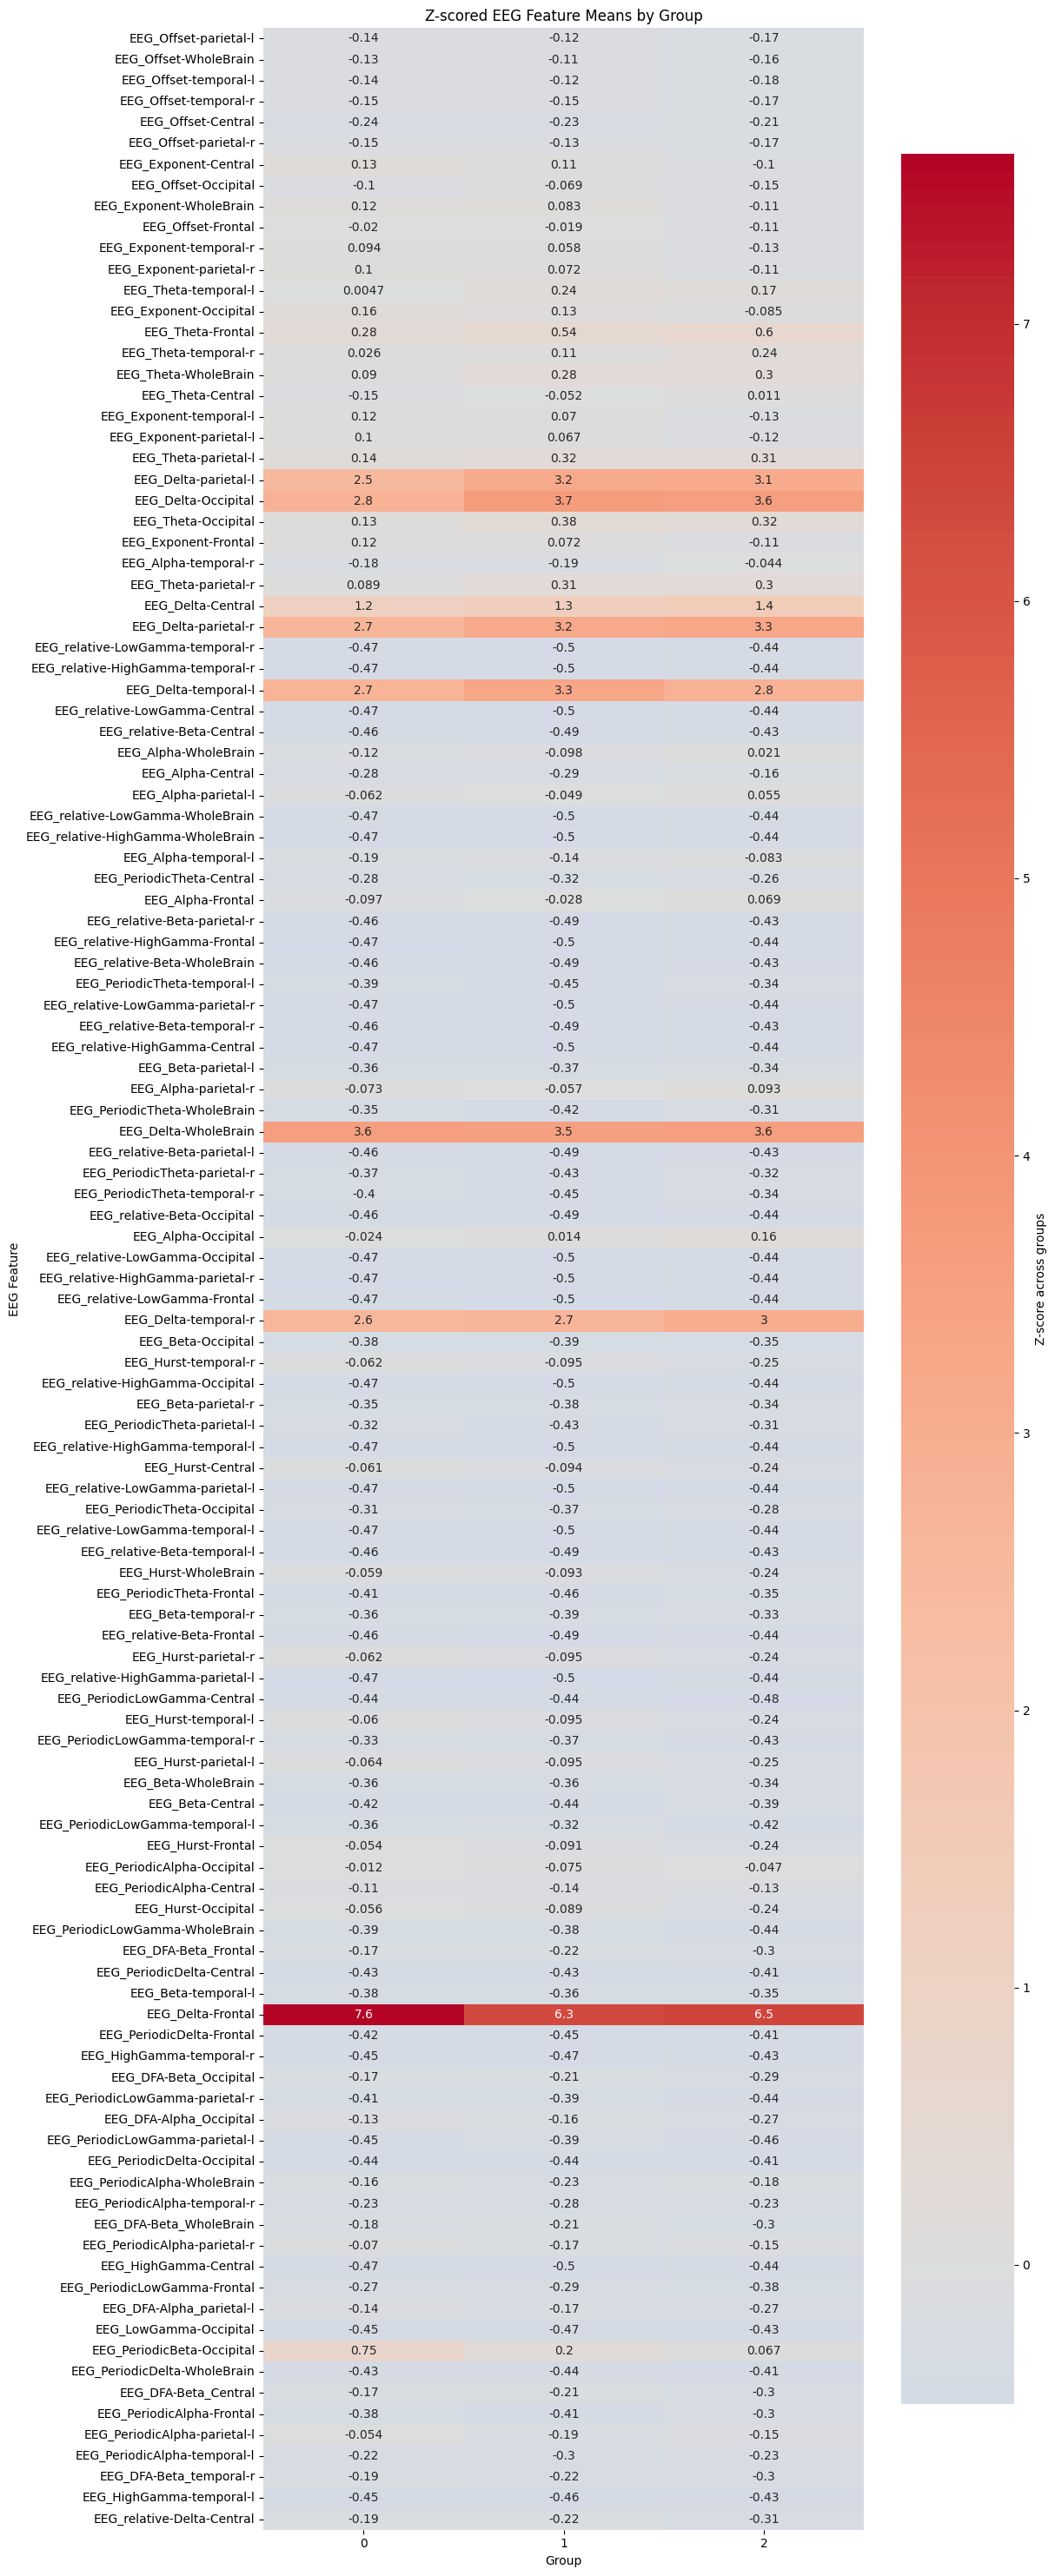

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Compute group means for significant features only
group_col = 'diagnostic_group'
features_to_plot = signif_features  # from your ANOVA results

group_means = df.groupby(group_col)[features_to_plot].mean()

# 2. Optional: Z-score features across groups (row-wise)
# This helps with visual contrast
scaler = StandardScaler()
group_means_z = pd.DataFrame(
    scaler.fit_transform(group_means.T),
    index=group_means.columns,
    columns=group_means.index
)

# 3. Plot heatmap
plt.figure(figsize=(12, max(6, len(features_to_plot) * 0.25)))  # adapt size
sns.heatmap(group_means_z, annot=True, cmap='coolwarm', center=0,
            cbar_kws={'label': 'Z-score across groups'})
plt.title('Z-scored EEG Feature Means by Group')
plt.xlabel('Group')
plt.ylabel('EEG Feature')
plt.tight_layout()
plt.show()


🔍 Big Picture Observations:
1. Age is significantly different across groups
🔴 Group 0 (control) has very high Z-scored age (Z ≈ 6.5!)

🔵 Groups 1 and 2 have much lower age

→ Age should be considered as a covariate in regression later to control for confounding.

2. Delta power (especially in temporal and parietal regions)
EEG_Delta-parietal-l, EEG_Delta-temporal-r, EEG_Delta-WholeBrain:

🔴 Strongest in Group 2 (genetic neurodev)

⚪️ Medium in Group 1

🔵 Lowest in Group 0

✅ Interpretation:

Suggests elevated delta power in temporal/parietal regions in genetic carriers, a known neurodevelopmental biomarker pattern.

3. Relative Low Gamma + High Gamma is decreased in neurodev groups
Features like EEG_relative-LowGamma-Central, EEG_relative-HighGamma-temporal-r, etc.

🔵 Control group shows higher values

🔴 Strong reductions in both neurodev groups, especially Group 2

✅ Interpretation:

Decreased gamma power has been linked to altered cortical processing and excitation-inhibition imbalance, often observed in ASD and other neurodev conditions.

4. Theta and Alpha offsets/exponents
Example: EEG_Exponent-Central, EEG_Offset-temporal-r

Tend to be higher in controls, lower in neurodev groups

Subtle gradient from Group 0 → 1 → 2

✅ Interpretation:

These reflect differences in aperiodic (1/f) activity — could suggest neural noise or altered baseline activity increasing with severity/genetic load.

5. Control group consistently shows higher spectral complexity
Across high frequency (gamma) and across offset/exponent features, Group 0 = higher, Group 2 = lower.

✅ Interpretation:

The controls show more typical spectral structure, while neurodev + genetic groups show flatter spectra and lower gamma = possible signs of reduced cortical differentiation or maturational delay.

### Multiple Regression

In [ ]:
# Multiple regression for each EEG feature
import statsmodels.api as sm

print("\nMultiple Regression Results:")
print("-" * 50)

# Create dummy variables for diagnostic groups
diagnostic_dummies = pd.get_dummies(df['diagnostic_group'], prefix='group')

for eeg_feature in eeg_cols:
    try:
        # Prepare X (predictors) and y (dependent variable)
        X = diagnostic_dummies
        y = pd.to_numeric(df[eeg_feature], errors='coerce')
        
        # Remove rows with NaN values
        mask = ~y.isna()
        X = X[mask]
        y = y[mask]
        
        if len(y) == 0:
            print(f"\nSkipping regression for {eeg_feature} - no valid data")
            continue
            
        # Add constant
        X = sm.add_constant(X)
        
        # Fit model
        model = sm.OLS(y, X).fit()
        
        # Print results
        print(f"\nDependent Variable: {eeg_feature}")
        print(model.summary().tables[1])
        
    except Exception as e:
        print(f"\nError in regression for {eeg_feature}: {str(e)}")
